<a href="https://colab.research.google.com/github/mohamadarif03/11-Mohamad-Arif/blob/main/11_MohamadArif_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA and Early Preprocessing Assignments

**Name: Mohamad Arif**

---

This notebook contains assignments focused on **Exploratory Data Analysis (EDA)** and **Early Preprocessing** techniques.

All questions and exercises in this notebook will refer to the **amazon_delivery.csv** dataset.

Dataset source : https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset

## 1. Dataset Understanding & EDA

Inspect this dataset and answer the following questions:

a. Identify at least 4 variables in the dataset that could potentially affect delivery time.

b. Classify these variables into:
- Numerical
- Categorical

c. If you want to perform initial EDA, mention three most relevant visualizations to understand the data distribution in this dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://drive.google.com/uc?export=download&id=17ZkJnKmQAgFTYv8SFY6DRiy9sJ2GeRM9"

df = pd.read_csv(url)
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [4]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')

In [5]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [7]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [8]:
cat = df.select_dtypes(include="object").columns
num = df.select_dtypes(include=np.number).columns
print(f"Variabel-variabel kategorikal: {cat}")
print(f"Variabel-variabel numerik: {num}")

Variabel-variabel kategorikal: Index(['Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather',
       'Traffic', 'Vehicle', 'Area', 'Category'],
      dtype='object')
Variabel-variabel numerik: Index(['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude',
       'Drop_Latitude', 'Drop_Longitude', 'Delivery_Time'],
      dtype='object')


## Answer

### a. Variabel yang Berpotensi Mempengaruhi Delivery Time

Menurut saya, 4 variabel yang kemungkinan memiliki potensi memengaruhi **delivery time**, yaitu:

* **Weather** (kondisi cuaca)
* **Traffic** (kondisi lalu lintas)
* **Vehicle** (jenis kendaraan yang digunakan)
* **Jarak toko dengan lokasi pemesan**, yang dapat dihitung berdasarkan:

  * `Store_Latitude`
  * `Store_Longitude`
  * `Drop_Latitude`
  * `Drop_Longitude`

### b. Klasifikasi Variabel

**1. Variabel Kategorikal**

```
["Weather", "Traffic", "Vehicle", "Area", "Category"]
```

**2. Variabel Numerik**

```
["Agent_Age", "Agent_Rating", "Store_Latitude", "Store_Longitude", "Drop_Latitude", "Drop_Longitude"]
```
### c. Visualisasi
Ada di sell bawah ini untuk jawaban no 1 (c). Pokoknya sebelum angka 2 itu jawaban 1.c

<Axes: xlabel='Delivery_Time', ylabel='Count'>

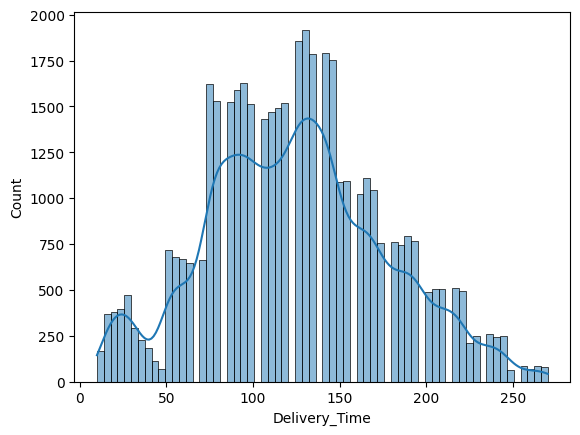

In [9]:
sns.histplot(df["Delivery_Time"], kde=True)

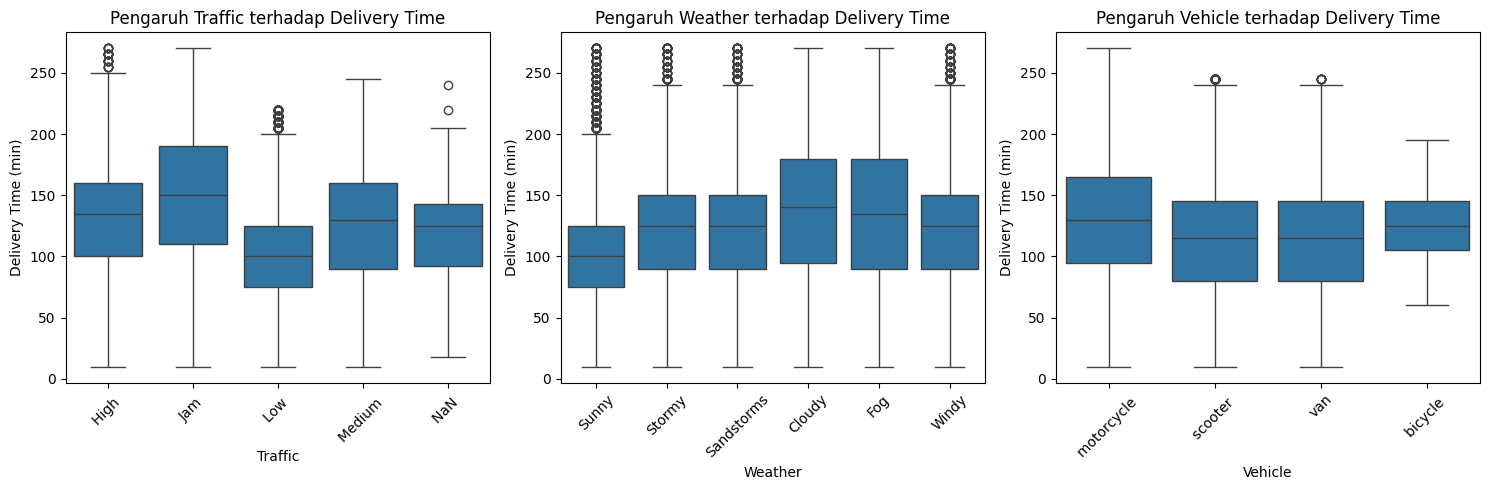

In [10]:
cat_var = ["Traffic", "Weather", "Vehicle"]
plt.figure(figsize=(15, 5))

for i, var in enumerate(cat_var, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=var, y="Delivery_Time", data=df)
    plt.title(f"Pengaruh {var} terhadap Delivery Time")
    plt.xlabel(var)
    plt.ylabel("Delivery Time (min)")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2. The Right Visualization?

You want to understand the relationship between traffic conditions (Traffic) and delivery time (Delivery Time) using the Amazon delivery dataset.

a. Create at least 3 visualizations to identify this relationship and explain why you chose those visualizations!

b. What insights can be obtained from these visualizations regarding the effect of traffic conditions on delivery time?

c. If you want to know the variability of delivery time for each traffic condition, what visual elements should you pay attention to on the graph?

In [11]:
df['Traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [12]:
df['Traffic'] = df['Traffic'].replace('NaN ', np.nan)
df['Traffic'].isnull().sum()

np.int64(91)

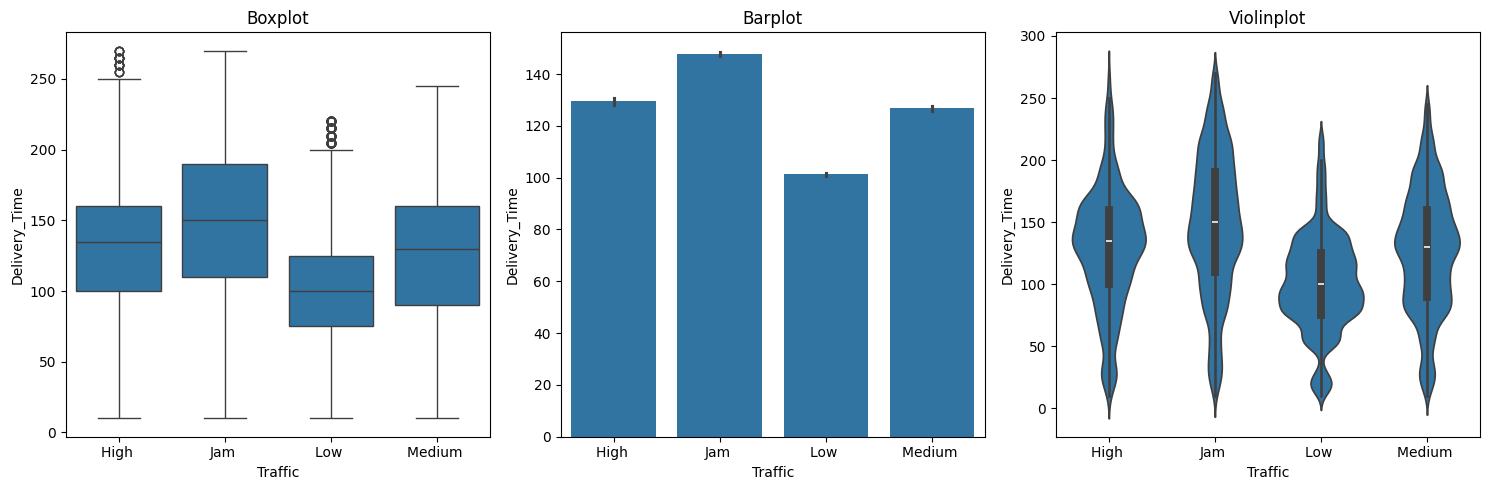

In [13]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(x='Traffic', y='Delivery_Time', data=df)
plt.title('Boxplot')

plt.subplot(1,3,2)
sns.barplot(x='Traffic', y='Delivery_Time', data=df)
plt.title('Barplot')

plt.subplot(1,3,3)
sns.violinplot(x='Traffic', y='Delivery_Time', data=df)
plt.title('Violinplot')

plt.tight_layout()
plt.show()

# Answer
### A. Alasan Pemilihan Visualisasi

Alasan saya memilih **boxplot** yaitu saya ingin menampilkan sebuah visualisasi yang dapat menunjukkan **rentang data, outlier, dan median** pada tiap level kemacetan.

Sedangkan **barplot** saya memilihnya karena itu merupakan cara paling simpel untuk menunjukkan **perbedaan nilai rata-rata pengiriman secara langsung**.

Sedangkan **violin plot** mirip dengan boxplot, namun kita juga bisa melihat **kepadatan distribusi data**. Dengan begitu, kita dapat melihat pada **rentang menit berapa pesanan paling banyak menumpuk** pada tiap kondisi *traffic*.
### B. Insight dari Visualisasi

Berdasarkan visualisasi tersebut, wawasan yang saya dapatkan yaitu **kedua kolom tersebut berkorelasi positif**. Seperti yang dapat kita lihat, ketika **traffic** bernilai *low*, rata-rata waktu pengirimannya **lebih cepat** daripada *medium*. Begitu juga dengan *medium* yang **lebih cepat** daripada *high*, dan seterusnya.

Hal ini menunjukkan bahwa **semakin tinggi tingkat kemacetan (traffic)**, maka **semakin lama waktu pengiriman (delivery time)** yang dibutuhkan.

### C. Visualisasi dari Variasi

Jika saya ingin melihat **variasinya**, tentu saja saya menggunakan visualisasi **boxplot**. Karena pada **boxplot** terdapat atau ditunjukkan **range dari datanya, median, bahkan outlier-outliernya**, sehingga kita dapat melihat bagaimana penyebaran data pada setiap kategori dengan lebih jelas.

## 3. What can cause delivery time to be long or short?

As an analyst, you want to know what factors most influence delivery time.

a. What visualization is most appropriate for comparing delivery time by vehicle type? Include the visualization to support your argument!

b. If you want to see the relationship between traffic level and delivery time, what graph should be used?

c. Explain the operational insights that can be obtained from this analysis.

<Axes: xlabel='Vehicle', ylabel='Delivery_Time'>

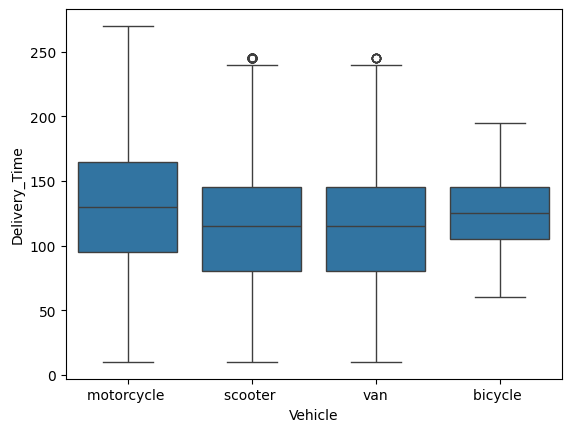

In [15]:
sns.boxplot(x='Vehicle', y='Delivery_Time', data=df)

<Axes: xlabel='Traffic', ylabel='Delivery_Time'>

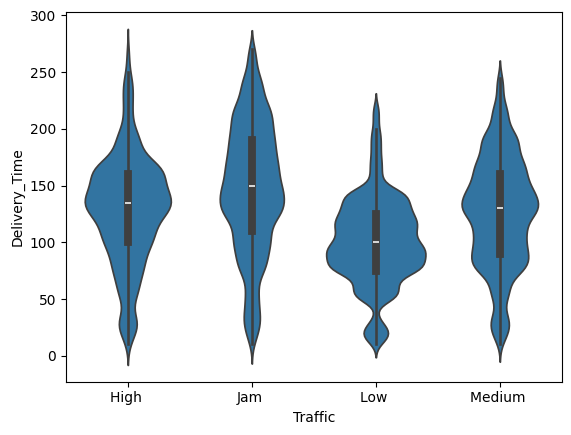

In [18]:
sns.violinplot(x="Traffic", y="Delivery_Time", data=df)

## Answer

**A.**  
Saya untuk melakukan visualisasi perbandingan waktu pengiriman berdasarkan tipe kendaraan dapat menggunakan **box plot**. Kenapa? karena saya bisa melihat sebaran data tersebut, apakah motor lebih konsisten, atau kendaraan-kendaraan tertentu yang sering mengalami keterlambatan.

**B.**  
Untuk melihat hubungan tingkat kemacetan dan waktu pengiriman saya menggunakan **Violin plot** ataupun **Boxplot**.

**C.**
Berdasarkan hasil analisis yang saya lakukan pada hubungan traffic dan kendaraan. Berdasarkan chart, menunjukkan bawa ternyata motorlah yang memiliki rata rata waktu distribusi yang paling lama dibandingkan lainnya. Disusul dengan sepeda, van dan juga scooter. Namun, saya disini belum bisa menyimpullkan bahwasanya dengan menggunakan motor itu membuat waktu pengantaran lebih lama, dikarenakan bisa saja ada faktor lain yang menyebabkan motor itu waktu pengantaran menjadi lama, mungkin kalau hipotesis saya dikarenakan motor mungkin sering digunakan untuk mengantarkan yang jaraknya jauh

Kemudian untuk traffic sendiri sydag sesyau denggan hipotesis awal, jadi yang tingkat kemacetannya rendah itu memiliki rata rata lebih cepat sedangkan yang jauh itu lebih lama

## 4. Your Boss Said: "Fix this bad graph, please."

Below is a poorly designed pie chart. Identify at least 3 problems with this visualization, then create a better version of this graph.

![Bad Graph](https://drive.google.com/uc?export=view&id=1jWZUXfLAhIRHyTsyO82j-ccWGP8afBt7)

**Kekurangan Chart:**

Menurut saya terdapat beberapa kekurangan pada chart tersebut:

1. **Terlalu banyak kategori.**  
   Pada chart tersebut terdapat kurang lebih **15+ irisan**, sehingga visualisasi menjadi terlalu padat dan sulit untuk dibaca secara cepat.

2. **Sulit membandingkan antar irisan.**  
   Meskipun sudah terdapat persentase pada setiap bagian, secara visual ukuran irisan terlihat hampir identik sehingga tetap sulit untuk melakukan perbandingan secara jelas.

3. **Kurang cocok untuk data kontinu.**  
   Data yang digunakan merupakan **data kontinu**, sehingga kurang cocok jika divisualisasikan menggunakan **pie chart**.

**Menurut saya, distribusi ini lebih cocok untuk ditampilkan menggunakan diagram batang ataupun histplot**

<Axes: xlabel='Delivery_Time', ylabel='Count'>

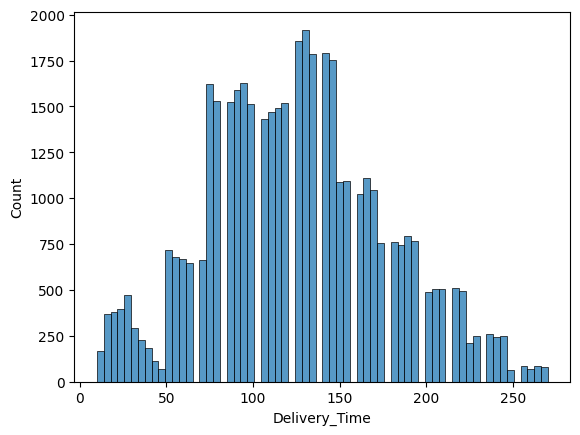

In [22]:
sns.histplot(x=df["Delivery_Time"], data=df)

## 5. "Why does this graph hurt my eyes?"

Below is a visualization with terrible color choices. Identify at least 3 color-related problems and explain why they make the graph difficult to read. Then, recreate this graph with a proper color scheme.

![Bad Colors](https://drive.google.com/uc?export=view&id=1_wm075VK_cvV5NUWU2Knuhi8atzw0o8H)

**Permasalahannya:**

1. **Kontras warnanya yang buruk.**  
   Penggunaan warna teks yang cerah dengan latar belakang putih sangat sulit untuk dilihat.

2. **Warna vibrant yang digunakan terlihat menyatu.**  
   Warna-warna yang digunakan terlihat seperti menyatu satu sama lain sehingga sulit dibedakan secara visual.

3. **Skema warnanya terlihat tidak konsisten.**  
   Penggunaan warna pada chart terlihat tidak konsisten sehingga dapat membingungkan pembaca.

/tmp/ipykernel_535/977257221.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Delivery_Time', data=df, palette='Set2')


<Axes: xlabel='Weather', ylabel='Delivery_Time'>

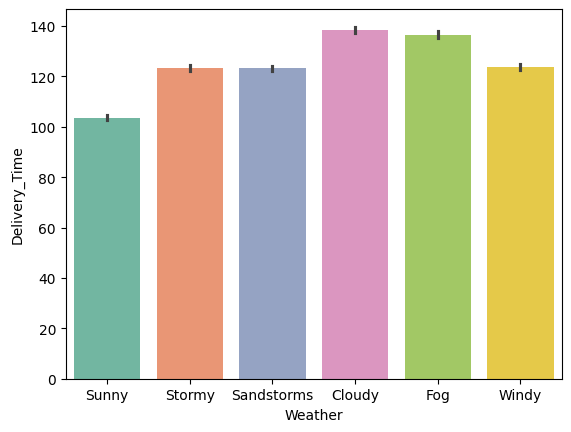

In [26]:
sns.barplot(x='Weather', y='Delivery_Time', data=df, palette='Set2')

---

## Good Luck!

Remember: EDA is 80% staring at data and 20% making graphs that your boss will ask you to "fix" anyway.

*"The pain you feel today will be the strength you feel tomorrow... or at least that's what we tell ourselves when the data doesn't make sense."*

Happy analyzing!

> *"EDA is like therapy for your data — you uncover its issues, clean up its mess, and try to understand why it behaves the way it does. Good luck, and have fun with the pain!"*